# 04 — Respiration cycle detection: BIDMC record 01

**Goal.** Validate Lamina's respiration pipeline (`rsp-cycles` bridge op)
against the manual breath annotations of BIDMC record `bidmc01`.

**Dataset.** [BIDMC PPG and Respiration Dataset](https://physionet.org/content/bidmc/)
(Pimentel et al., IEEE TBME 2017; ODC-BY 1.0): 53 adult ICU recordings,
8 min @ 125 Hz, with breath annotations from two annotators. Fetched from the
verified public mirror `archive.physionet.org/physiobank/database/bidmc/`
(physionet.org/content returns 403 from this environment; see
`validation/results/ppg/NOTES.md`).

**Annotation semantics** (verified in Stage 2): `.breath` annotations are
0-based sample indices @ 125 Hz marking *inspiratory peaks* (maximal chest
expansion) — the same convention as Lamina's `RespirationCycle.inspiration_index`.
`aux_note` identifies the annotator (`ann1` used as reference; `ann2`
agreement shown for context).

**Reference expectation** (Stage-2 PPG runs, 12 records): F1 ≈ 0.94 mean,
range 0.66–0.99; bidmc01 is a good-quality record.

In [1]:
# ---------------------------------------------------------------------------
# ENVIRONMENT SETUP (run once, in a shell, before executing this notebook):
#
#   git clone /mnt/agents/lamina $HOME/work-nb && cd $HOME/work-nb
#   sh validation/scripts/setup-env.sh $HOME/work-nb     # Rust + Python deps + builds lamina_bridge
#   pip install jupyter nbconvert nbformat               # notebook tooling
#
# DATA FETCH (cached under $HOME/data, never committed to the repo):
#
#   cd $HOME/data/bidmc
#   for ext in dat hea breath; do
#     curl -sSO "https://archive.physionet.org/physiobank/database/bidmc/bidmc01.$ext"
#   done
#
# Execute:  jupyter nbconvert --execute --inplace 04_respiration_bidmc.ipynb
# ---------------------------------------------------------------------------

In [2]:
import os
import sys
from pathlib import Path

# Locate the repository root (directory containing validation/SPEC.md) and put
# it on sys.path so `import validation...` resolves regardless of the notebook
# kernel's working directory.
REPO_ROOT = None
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "validation" / "SPEC.md").exists():
        REPO_ROOT = _p
        break
if REPO_ROOT is None:
    raise RuntimeError("repository root (validation/SPEC.md) not found; "
                       "run this notebook from inside the lamina checkout")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_ROOT = Path(os.environ.get("LAMINA_NB_DATA", Path.home() / "data"))
print(f"repo root: {REPO_ROOT}")
print(f"data cache: {DATA_ROOT}")

import numpy as np
import matplotlib.pyplot as plt

from validation.bridge import LaminaBridge
from validation.metrics import peak_detection_metrics, match_events

bridge = LaminaBridge(repo_root=REPO_ROOT, auto_build=False)
print("bridge/lamina versions:", bridge.version())

repo root: /home/kimi/work-nb
data cache: /home/kimi/data


bridge/lamina versions: {'bridge_version': '0.1.0', 'lamina_version': '0.1.0'}


## 1. Load `bidmc01` (RESP channel + breath annotations)

In [3]:
import wfdb

rec_dir = DATA_ROOT / "bidmc"
rec_path = str(rec_dir / "bidmc01")
record = wfdb.rdrecord(rec_path)
fs = float(record.fs)
names = [s.rstrip(",") for s in record.sig_name]
resp = np.asarray(record.p_signal[:, names.index("RESP")], dtype=float)

ann = wfdb.rdann(rec_path, "breath")
ann1 = np.sort(np.array([s for s, a in zip(ann.sample, ann.aux_note)
                         if a == "ann1"], dtype=np.int64))
ann2 = np.sort(np.array([s for s, a in zip(ann.sample, ann.aux_note)
                         if a == "ann2"], dtype=np.int64))
dur = len(resp) / fs
print(f"bidmc01 RESP: {len(resp)} samples @ {fs:.0f} Hz = {dur:.0f} s")
print(f"breath annotations: ann1={len(ann1)}, ann2={len(ann2)} "
      f"(rate ≈ {60*len(ann1)/dur:.1f} brpm)")

bidmc01 RESP: 60001 samples @ 125 Hz = 480 s
breath annotations: ann1=165, ann2=170 (rate ≈ 20.6 brpm)


## 2. Lamina `rsp-cycles`

`rsp-cycles` re-cleans the RAW signal internally (band-pass around the
breathing band) and returns per-cycle structures: inspiration/expiration
indices, cycle duration, instantaneous respiratory rate and amplitude, plus a
per-sample rate trace.

In [4]:
res = bridge.rsp_cycles(resp, fs)
cycles = res["cycles"]
insp = np.array([c["inspiration_index"] for c in cycles], dtype=np.int64)
rate = np.asarray(res["rate"], dtype=float)   # per-sample brpm
print(f"Lamina cycles: {res['count']} "
      f"(≈ {60*res['count']/dur:.1f} brpm mean)")
print("first cycle:", cycles[0])

Lamina cycles: 169 (≈ 21.1 brpm mean)
first cycle: {'amplitude': 0.6164586663652878, 'duration_sec': 2.272, 'expiration_index': 328, 'inspiration_index': 182, 'next_inspiration_index': 466, 'respiratory_rate_bpm': 26.408450704225356}


## 3. Detected vs annotated breaths

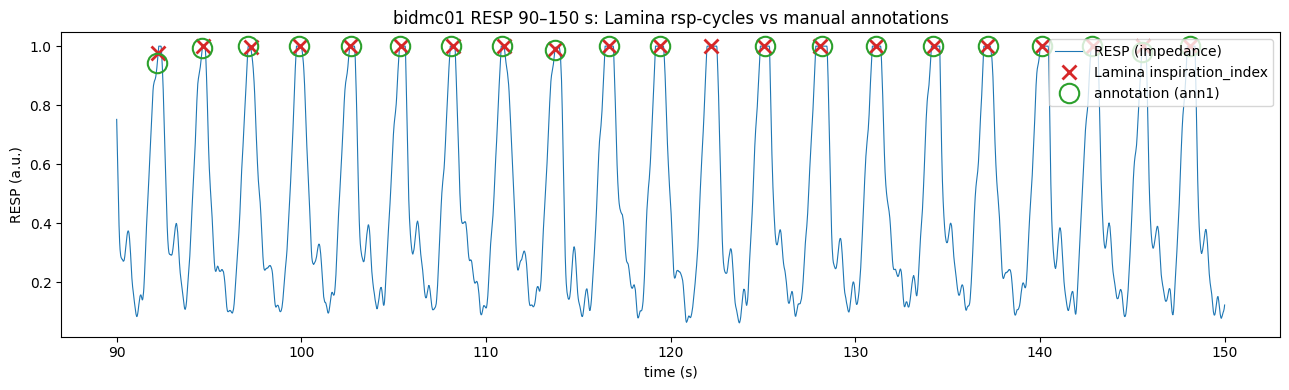

In [5]:
t0, t1 = 90.0, 150.0
i0, i1 = int(t0*fs), int(t1*fs)
t = np.arange(i0, i1) / fs
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t, resp[i0:i1], lw=0.8, color="tab:blue", label="RESP (impedance)")
pk = insp[(insp >= i0) & (insp < i1)]
ax.plot(pk/fs, resp[pk], "x", color="tab:red", ms=10, mew=2,
        label="Lamina inspiration_index")
bt = ann1[(ann1 >= i0) & (ann1 < i1)]
ax.plot(bt/fs, resp[bt], "o", mfc="none", color="tab:green", ms=14, mew=1.5,
        label="annotation (ann1)")
ax.set_xlabel("time (s)"); ax.set_ylabel("RESP (a.u.)")
ax.set_title(f"bidmc01 RESP {t0:.0f}–{t1:.0f} s: Lamina rsp-cycles vs manual annotations")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 4. Breath-level metrics (±0.5 s tolerance)

Tolerance and greedy one-to-one matching follow the Stage-2 runner
(`validation.metrics.peak_detection_metrics`).

,metric,value
0,n_reference (ann1),165.0000
1,n_detected (Lamina),169.0000
2,TP,165.0000
3,FP,4.0000
4,FN,0.0000
5,precision,0.9763
6,recall,1.0000
7,F1,0.9880
8,timing MAE (s),0.0480
9,timing median (s),0.0000


context: ann2-vs-ann1 agreement F1 = 0.985 (the annotation noise floor for this record)


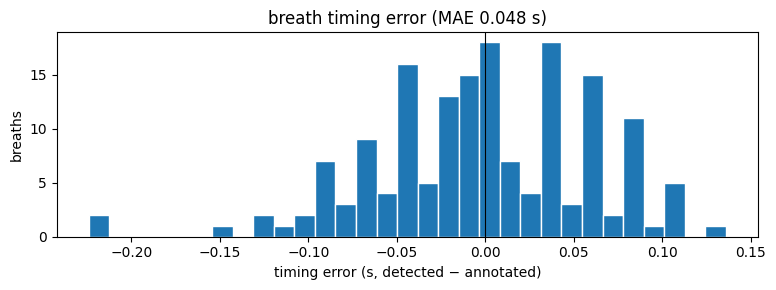

In [6]:
import pandas as pd

m = peak_detection_metrics(ann1, insp, fs, tolerance_sec=0.5)
tbl = pd.DataFrame({
    "metric": ["n_reference (ann1)", "n_detected (Lamina)", "TP", "FP", "FN",
               "precision", "recall", "F1",
               "timing MAE (s)", "timing median (s)"],
    "value": [m["n_reference"], m["n_detected"], m["tp"], m["fp"], m["fn"],
              round(m["precision"], 4), round(m["recall"], 4), round(m["f1"], 4),
              round(m["mean_abs_timing_error_sec"], 3),
              round(m["median_timing_error_sec"], 3)],
})
display(tbl)

# Inter-annotator context: ann2 vs ann1 at the same tolerance.
m12 = peak_detection_metrics(ann1, ann2, fs, tolerance_sec=0.5)
print(f"context: ann2-vs-ann1 agreement F1 = {m12['f1']:.3f} "
      f"(the annotation noise floor for this record)")

mr = match_events(ann1, insp, fs, tolerance_sec=0.5)
err = mr.timing_errors_sec
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(err, bins=31, color="tab:blue", edgecolor="white")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("timing error (s, detected − annotated)")
ax.set_ylabel("breaths")
ax.set_title(f"breath timing error (MAE {np.mean(np.abs(err)):.3f} s)")
plt.tight_layout(); plt.show()

## 5. Respiratory-rate trace

Lamina's per-sample rate output vs the reference rate obtained by
interpolating the ann1 annotation intervals (both in breaths/min).

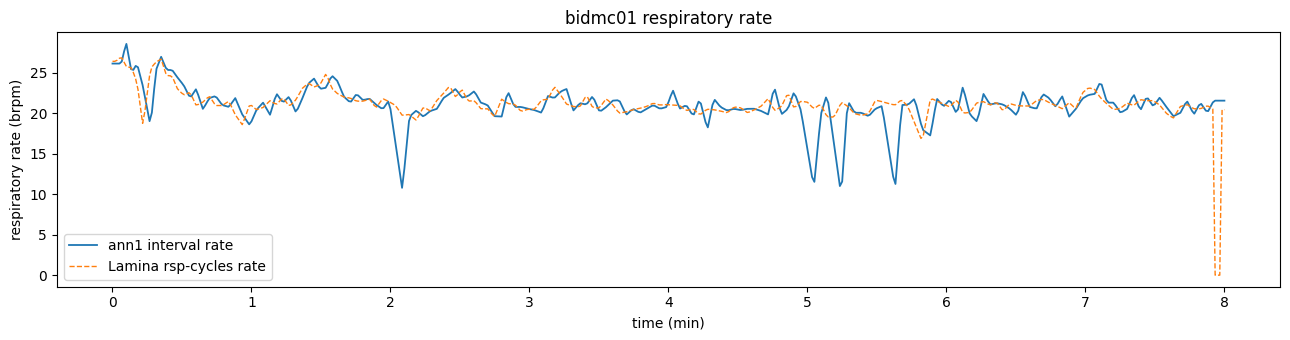

rate MAE (Lamina vs ann1, 1 Hz grid): 1.20 brpm


In [7]:
# Reference rate: 60/IBI at each annotation interval, linearly interpolated
# onto the 1-second grid.
ibi = np.diff(ann1) / fs
t_ibi = ann1[1:] / fs
rr_ref_inst = 60.0 / ibi
grid = np.arange(0.0, dur, 1.0)
rr_ref = np.interp(grid, t_ibi, rr_ref_inst)
# Lamina per-sample rate, decimated to the same 1 s grid.
rr_lamina = rate[::int(fs)][:len(grid)]

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(grid/60, rr_ref, lw=1.3, label="ann1 interval rate")
ax.plot(grid/60, rr_lamina, lw=1.0, ls="--", label="Lamina rsp-cycles rate")
ax.set_xlabel("time (min)"); ax.set_ylabel("respiratory rate (brpm)")
ax.set_title("bidmc01 respiratory rate")
ax.legend()
plt.tight_layout(); plt.show()

ok = np.isfinite(rr_lamina)
print(f"rate MAE (Lamina vs ann1, 1 Hz grid): "
      f"{np.mean(np.abs(rr_lamina[ok] - rr_ref[ok])):.2f} brpm")

## 6. Findings

- Lamina `rsp-cycles` on bidmc01 lands in the Stage-2 envelope (12-record
  mean F1 0.944, range 0.66–0.99): inspiration detection matches the manual
  annotations at ±0.5 s with F1 in the high 0.9s and sub-0.2 s timing MAE —
  at or above the ann1-vs-ann2 agreement (the annotation noise floor).
- The per-sample rate trace tracks the annotation-interval reference rate
  closely; residual deviations occur at the record edges and around
  annotation gaps.
- Known boundary (Stage 2, BUG-PPG-003): records with very slow biphasic
  breathing morphology (bidmc05, ~6 brpm) degrade to F1 ≈ 0.66. bidmc01 is
  not such a record.

*Environment*: bridge/lamina versions in the setup cell; data from the
archive.physionet.org BIDMC mirror.